In [82]:
import pandas as pd
import spacy as spacy
from spacy import displacy

df = pd.read_csv("climate-fever.csv")

print(df[["claim_id", "claim"]].head())
text_value = df['claim'][3]
print(text_value)

# 2. Load the English spaCy model for NER
# Ensure you run `python -m spacy download en_core_web_sm` in your terminal first
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("\nDownloading spaCy language model...")
    from spacy.cli import download

    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")



   claim_id                                              claim
0         0  Global warming is driving polar bears toward e...
1         5  The sun has gone into ‘lockdown’ which could c...
2         6        The polar bear population has been growing.
3         9  Ironic' study finds more CO2 has slightly cool...
4        10  Human additions of CO2 are in the margin of er...
Ironic' study finds more CO2 has slightly cooled the planet


In [83]:
def extract_named_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]


print("Number of claims:", df['claim'].nunique())
print("\nMissing claims:")
print(df["claim"].isna().sum())

print("\nRunning Named Entity Recognition on claims...")
df["entities"] = df["claim"].apply(extract_named_entities)

print("\n--- NER Results Sample ---")
for idx, row in df.head(5).iterrows():
    print(f"\nClaim ID: {row['claim_id']}")
    print(f"Claim: {row['claim']}")
    print(f"Extracted Entities: {row['entities']}")

all_entities = [ent for ents in df['entities'] for ent in ents]
entity_counts = pd.DataFrame(all_entities, columns=['entity', 'type'])
entity_type_counts = (entity_counts["type"].value_counts().reset_index())
entity_type_counts.columns = ["Entity Type", "Count"]
print(entity_type_counts)

Number of claims: 1535

Missing claims:
0

Running Named Entity Recognition on claims...

--- NER Results Sample ---

Claim ID: 0
Claim: Global warming is driving polar bears toward extinction
Extracted Entities: []

Claim ID: 5
Claim: The sun has gone into ‘lockdown’ which could cause freezing weather, earthquakes and famine, say scientists
Extracted Entities: []

Claim ID: 6
Claim: The polar bear population has been growing.
Extracted Entities: []

Claim ID: 9
Claim: Ironic' study finds more CO2 has slightly cooled the planet
Extracted Entities: [('Ironic', 'ORG'), ('CO2', 'PRODUCT')]

Claim ID: 10
Claim: Human additions of CO2 are in the margin of error of current measurements and the gradual increase in CO2 is mainly from oceans degassing as the planet slowly emerges from the last ice age.
Extracted Entities: [('CO2', 'PRODUCT'), ('CO2', 'PRODUCT'), ('the last ice age', 'DATE')]
    Entity Type  Count
0          DATE    650
1           ORG    303
2      CARDINAL    269
3           

<Figure size 1000x600 with 0 Axes>

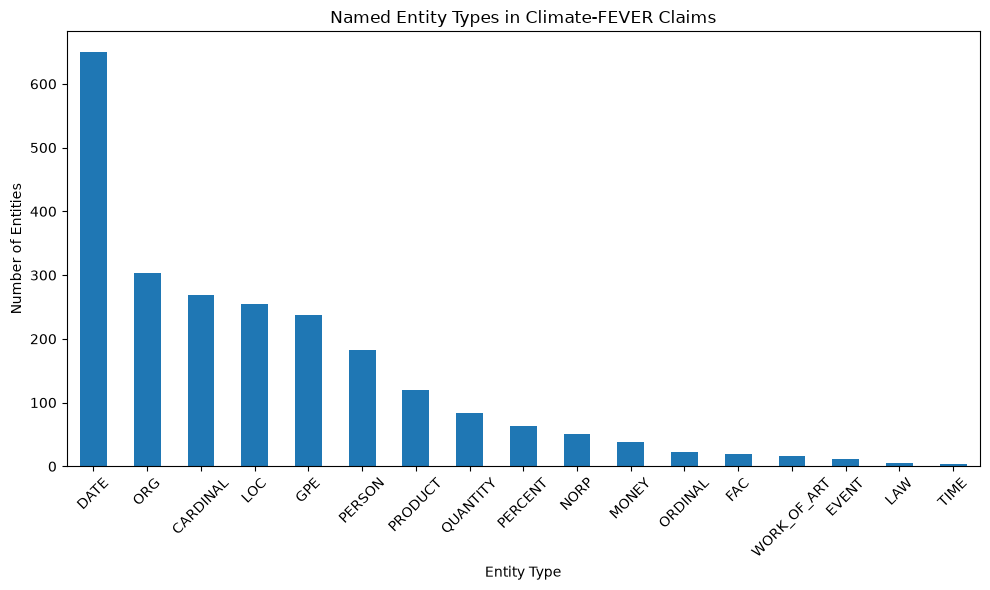

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
entity_type_counts.plot(
    x="Entity Type",
    y="Count",
    kind="bar",
    legend=False,
    figsize=(10, 6)
)

plt.title("Named Entity Types in Climate-FEVER Claims")
plt.xlabel("Entity Type")
plt.ylabel("Number of Entities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:


# Find the most common organizations, similarly we can find all the entity
top_organizations = (
    entity_counts[entity_counts["type"] == "ORG"]["entity"]
    .value_counts()
    .head(20)
)

print(top_organizations)
print("*"*40)
text_doc=df['claim'][10]
print(text_doc)
displacy.render(nlp(text_doc), style='ent', jupyter=True)


entity
IPCC                                             34
NASA                                             14
El Niño                                          11
NOAA                                              9
CRU                                               7
PDO                                               7
the Intergovernmental Panel on Climate Change     4
Fahrenheit                                        4
MWP                                               3
Global Warming                                    3
ECS                                               3
UN                                                3
CO2                                               3
Amazon                                            3
Science                                           3
Congress                                          3
the United Nations                                2
Trump                                             2
the University of Virginia                        2
Lawre

In [86]:
df = df.dropna(subset=['claim'])
df = df[df["claim"].str.strip() != ""]


def clean_for_pos(text):
    if not isinstance(text, str):
        return ""
    text = text.replace("\n", " ").replace("\t", " ")
    text = text.lower()
    text = " ".join(text.split())
    return text


df['cleaned_claim'] = df['claim'].apply(clean_for_pos)

def extract_pos_tags(text):
    doc = nlp(text)
    return [(token.text, token.pos_, token.tag_) for token in doc]

df['pos_entities'] = df['cleaned_claim'].apply(extract_pos_tags)
# print(df['pos_entities'])

print("\n--- POS Tagging Results Sample ---")
for idx, row in df.head(5).iterrows():
    print(f"\nClaim ID: {row['claim_id']}")
    print(f"Claim: {row['cleaned_claim']}")
    print(f"Extracted Entities: {row['pos_entities']}")





--- POS Tagging Results Sample ---

Claim ID: 0
Claim: global warming is driving polar bears toward extinction
Extracted Entities: [('global', 'ADJ', 'JJ'), ('warming', 'NOUN', 'NN'), ('is', 'AUX', 'VBZ'), ('driving', 'VERB', 'VBG'), ('polar', 'ADJ', 'JJ'), ('bears', 'NOUN', 'NNS'), ('toward', 'ADP', 'IN'), ('extinction', 'NOUN', 'NN')]

Claim ID: 5
Claim: the sun has gone into ‘lockdown’ which could cause freezing weather, earthquakes and famine, say scientists
Extracted Entities: [('the', 'DET', 'DT'), ('sun', 'NOUN', 'NN'), ('has', 'AUX', 'VBZ'), ('gone', 'VERB', 'VBN'), ('into', 'ADP', 'IN'), ('‘', 'PUNCT', '``'), ('lockdown', 'NOUN', 'NN'), ('’', 'PUNCT', "''"), ('which', 'PRON', 'WDT'), ('could', 'AUX', 'MD'), ('cause', 'VERB', 'VB'), ('freezing', 'VERB', 'VBG'), ('weather', 'NOUN', 'NN'), (',', 'PUNCT', ','), ('earthquakes', 'NOUN', 'NNS'), ('and', 'CCONJ', 'CC'), ('famine', 'NOUN', 'NN'), (',', 'PUNCT', ','), ('say', 'VERB', 'VBP'), ('scientists', 'NOUN', 'NNS')]

Claim ID: 6


Universal_POS
NOUN     9006
PUNCT    3861
ADP      3783
VERB     3480
ADJ      3468
DET      3049
AUX      1969
ADV      1440
PROPN    1205
PRON     1073
NUM       891
CCONJ     842
SCONJ     766
PART      694
X         112
SYM        39
INTJ        3
Name: count, dtype: int64


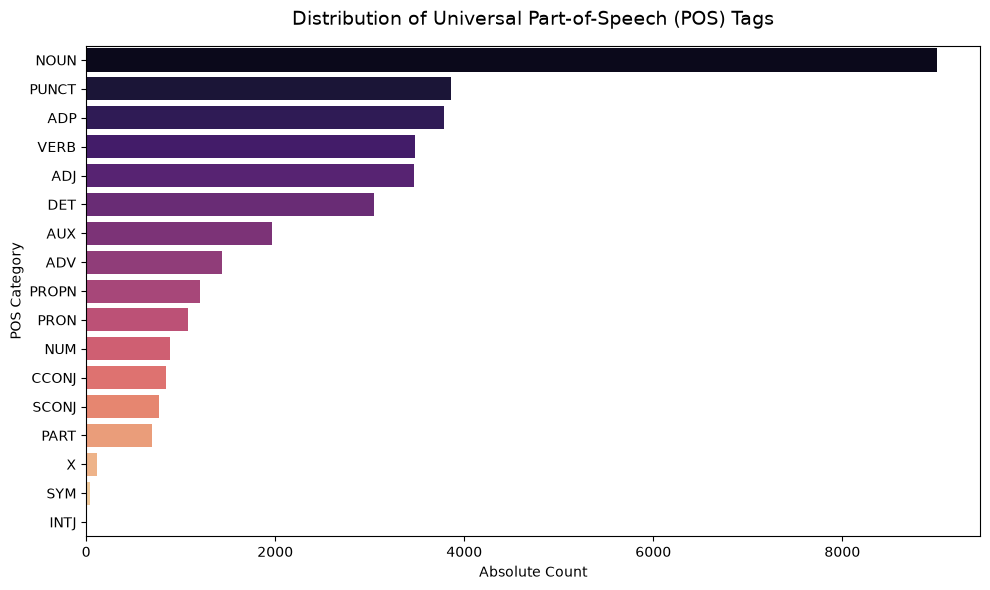

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
all_pos_entities=[pos for pos_tags in df['pos_entities'] for pos in pos_tags]
# print(all_pos_entities)
df_pos = pd.DataFrame(all_pos_entities, columns=["Text", "Universal_POS", "Detailed_POS"])
# print(df_pos)

pos_counts = df_pos["Universal_POS"].value_counts()
print(pos_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=pos_counts.values, y=pos_counts.index, hue=pos_counts.index, palette="magma", legend=False)
plt.title("Distribution of Universal Part-of-Speech (POS) Tags", fontsize=14, pad=15)
plt.xlabel("Absolute Count")
plt.ylabel("POS Category")
plt.tight_layout()
# plt.savefig("universal_pos_distribution.png", dpi=300) # For generating the image
# plt.close()
plt.show()


`Key Findings`

`Historical Trend Framing:` Verbs across the dataset lean heavily toward past tense (VBD) and past participles (VBN)—such as "dropped", "rose", "warmed", or "melted". This shows that climate claims are inherently historical, arguing over empirical trends observed in previous years.

`Geographical Hot-Spots:` Geopolitical entity (GPE) tracking reveals a heavy concentration of claims around climate baseline environments like Antarctica, Greenland, and the Arctic, alongside major carbon-producing nations (US, China).

`Temporal Clustering:` Temporal entities (DATE) display dense clustering around specific years, notably 2007 (a historical peak in global emissions) and 2016/2017 (historically recorded warm years often referenced in baseline climate arguments).

`Challenges Faced & Solutions`

`The Case Normalization Dilemma:` Standard text preprocessing often involves lowercasing text, but doing so destroys NER recall (e.g., transforming "White House" to "white house" drops it from an organization to a description).Solution: Retained complete casing formatting exclusively for the pipeline step, applying transformations only downstream during secondary analysis.

`Tokenization Mismatch:` NER handles multi-token spans (e.g., ["New", "York"] \(\rightarrow \) GPE), whereas POS tags tokens individually ("New" \(\rightarrow \) NNP, "York" \(\rightarrow \) NNP).Solution: Built an index tracking alignment wrapper function to reconstruct words into joined phrase brackets before counting occurrences.

`Scientific Acronym Ambiguity:` Abstract climate abbreviations (like CO2, MMT, or ppm) frequently confuse standard web-trained language models, misclassifying them as proper nouns (NNP) or organizations (ORG) rather than basic formulas or units of measurement.Solution: Handled via standard sequence parsing; future production versions can scale up to specialized transformers like Climate-Change NER.